# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [1]:
from Tools.DatasetTools.Commoms import *
dataset = 'Cr-Co-W'#'Fe-Mo/'
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer  import Featurizer

In [2]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)
Features = Featurizer(BS)

# Compositions 

# Population of phases

<AxesSubplot:xlabel='Phase', ylabel='Count'>

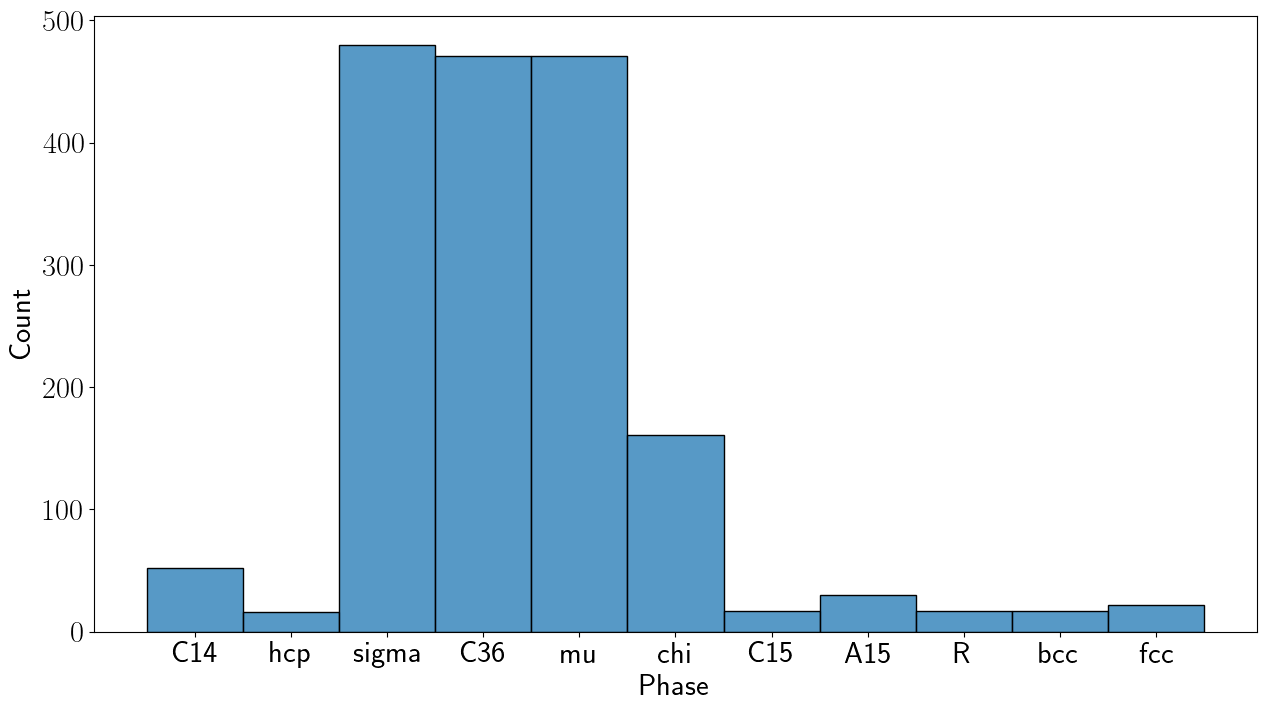

In [3]:
fig, ax = plt.subplots(figsize=(15,8))
sns.histplot(x = BS['Phase'], ax=ax)

<AxesSubplot:ylabel='Count'>

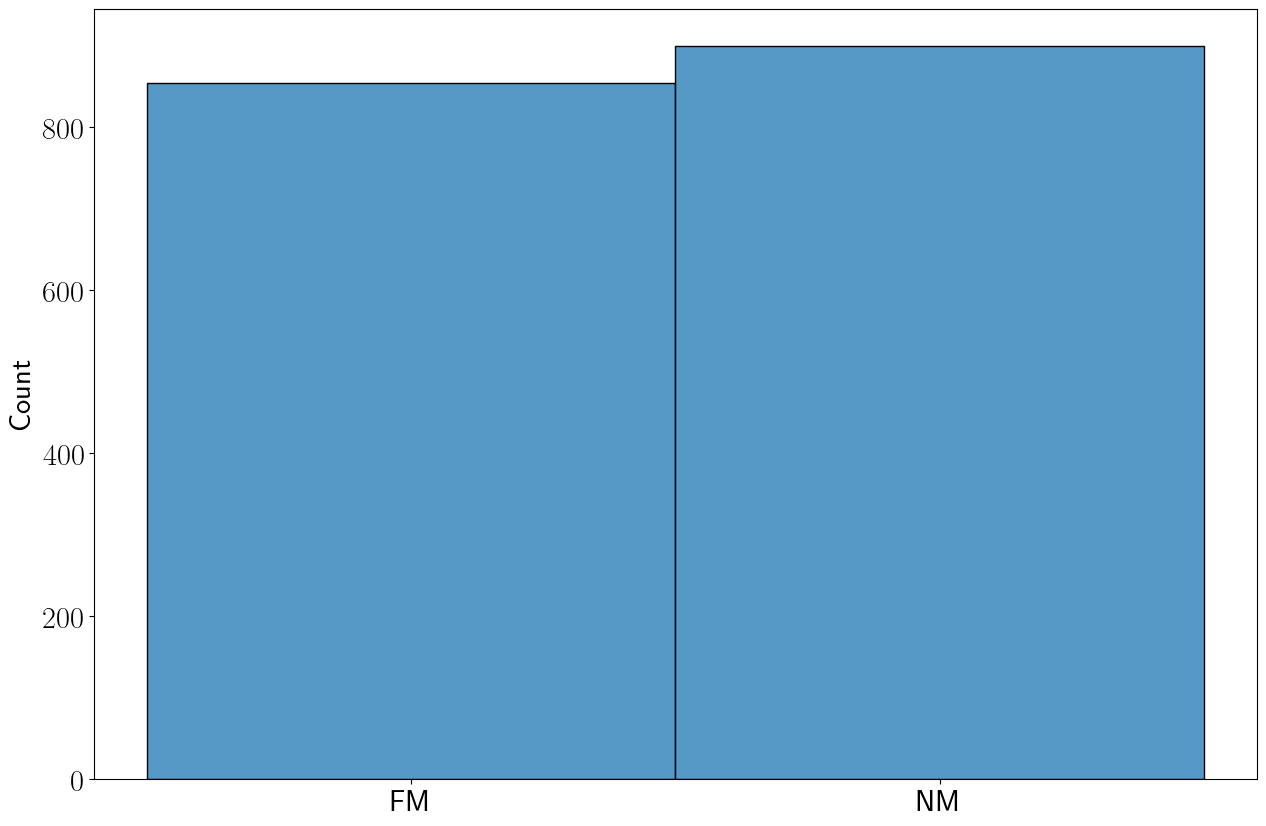

In [4]:
sns.histplot(x = Features.Mag)

In [5]:
isfm = Features.Mag.str.contains('FM')

In [6]:
fmsamples = BS.index[isfm]

In [7]:
fmsamplesasnm = fmsamples.str.replace('.FM$','.NM')

In [8]:
nmsamples = BS.index[~isfm]

## fm samples without nm counterpart:

In [9]:
nmsamples.difference(fmsamplesasnm)

Index(['Co_pv14W_sv10.C36-AABAB.NM', 'Co_pv14W_sv10.C36-BAAAB.NM',
       'Co_pv15W_sv38.R-AAAABBBBBBB.NM', 'Co_pv18W_sv6.C36-AAAAB.NM',
       'Co_pv1W_sv3.D03-AB3.NM', 'Co_pv1W_sv52.R-ABBBBBBBBBB.NM',
       'Co_pv21W_sv32.R-AAAAABBBBBB.NM', 'Co_pv27W_sv26.R-AAAAAABBBBB.NM',
       'Co_pv2W_sv11.mu-BBBAB.NM', 'Co_pv2W_sv11.mu-BBBBA.NM',
       'Co_pv2W_sv2.B32-AB.NM', 'Co_pv2W_sv6.D0_19-AB3.NM',
       'Co_pv33W_sv20.R-AAAAAAABBBB.NM', 'Co_pv3W_sv1.D03-A3B.NM',
       'Co_pv3W_sv10.mu-ABBBA.NM', 'Co_pv3W_sv50.R-AABBBBBBBBB.NM',
       'Co_pv45W_sv8.R-AAAAAAAAABB.NM', 'Co_pv47W_sv6.R-AAAAAAAAAAB.NM',
       'Co_pv4W_sv20.C36-ABBBB.NM', 'Co_pv4W_sv20.C36-BBABB.NM',
       'Co_pv4W_sv26.sigma-BABBB.NM', 'Co_pv4W_sv9.mu-BBAAB.NM',
       'Co_pv6.C15.NM', 'Co_pv6W_sv18.C36-BBBBA.NM',
       'Co_pv6W_sv2.D0_19-A3B.NM', 'Co_pv6W_sv24.sigma-AABBB.NM',
       'Co_pv8.A15.NM', 'Co_pv8W_sv16.C36-AABBB.NM',
       'Co_pv8W_sv16.C36-ABABB.NM', 'Co_pv8W_sv4.C14-BAA.NM',
       'Co_pv9W_sv44.R-AAAB

## nm samples as without fm counterpart:

In [10]:
fmsamplesasnm.difference(nmsamples)

Index(['Co_pv30.sigma_Co_pv.NM', 'Cr_pv11W_sv2.mu-AAAAB.NM',
       'Cr_pv1Co_pv1.B2-AB.NM', 'Cr_pv1Co_pv1.L10-NiAl-AB.NM',
       'Cr_pv1Co_pv1.hcp-AB.NM', 'Cr_pv1Co_pv3.L12-AB3.NM',
       'Cr_pv2Co_pv8W_sv3.mu-CBBCA.NM', 'Cr_pv30.sigma_Cr_pv.NM',
       'Cr_pv3Co_pv1.L12-A3B.NM', 'Cr_pv5Co_pv1W_sv2.A15-AAAAABCC.NM',
       'Cr_pv5Co_pv1W_sv2.A15-AAAABACC.NM',
       'Cr_pv5Co_pv1W_sv2.A15-AAABAACC.NM',
       'Cr_pv5Co_pv1W_sv2.A15-AABAAACC.NM',
       'Cr_pv5Co_pv1W_sv2.A15-ABAAAACC.NM',
       'Cr_pv5Co_pv1W_sv2.A15-BAAAAACC.NM',
       'Cr_pv5Co_pv2W_sv1.A15-AAAAACBB.NM',
       'Cr_pv5Co_pv2W_sv1.A15-AAAACABB.NM',
       'Cr_pv5Co_pv2W_sv1.A15-AAACAABB.NM',
       'Cr_pv5Co_pv2W_sv1.A15-AACAAABB.NM',
       'Cr_pv5Co_pv2W_sv1.A15-ACAAAABB.NM',
       'Cr_pv5Co_pv2W_sv1.A15-CAAAAABB.NM',
       'Cr_pv6Co_pv1W_sv1.A15-AAAAAABC.NM', 'W_sv4.fcc-cubic.NM'],
      dtype='object', name='index')

#  Obvious outliers removal

In [11]:
BS = BS[(BS.B0 > 0 ) ]

# Distribution of Target Variables 

## total energy

In [12]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

some obvious outliers:

In [13]:
if dataset == 'Cr-Co-W':
    BS = BS[(BS['E0']>-500) & (BS['V0']<40)]

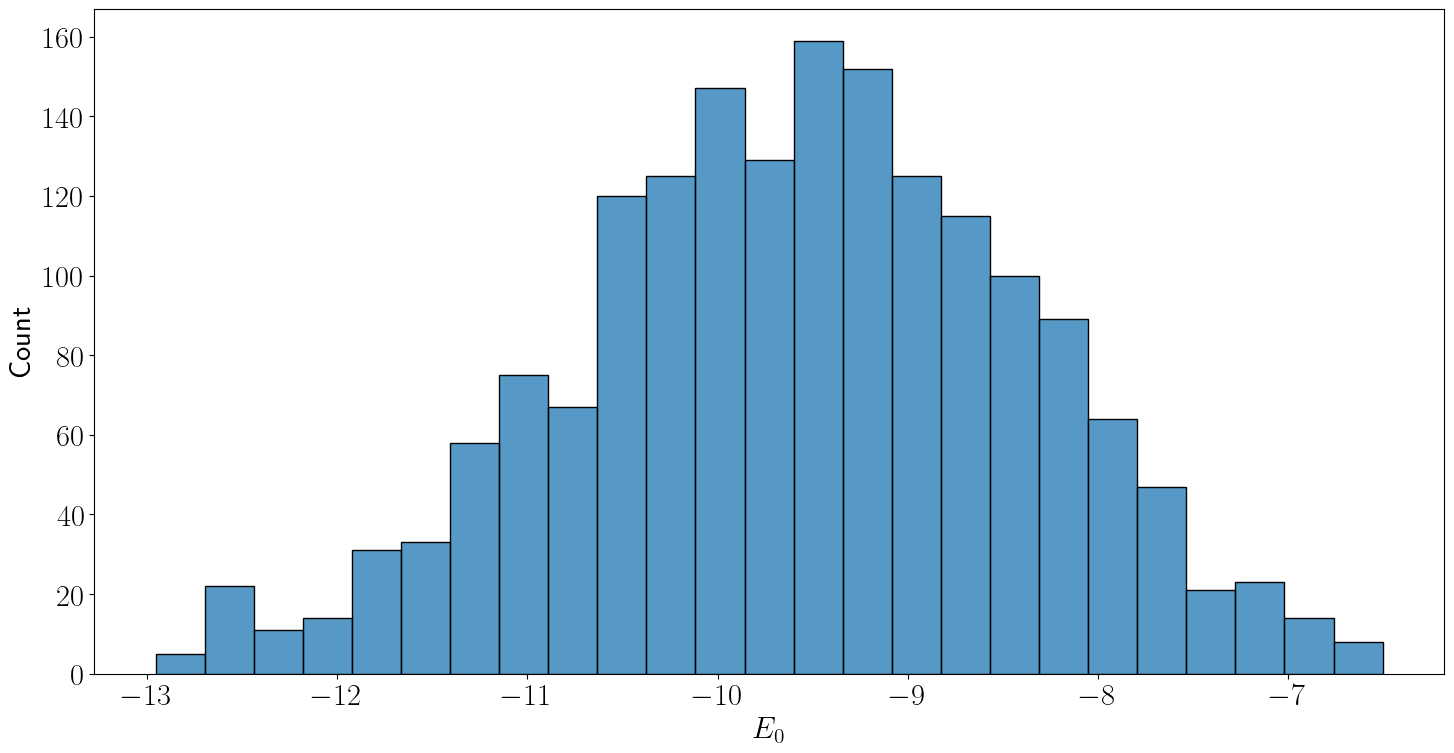

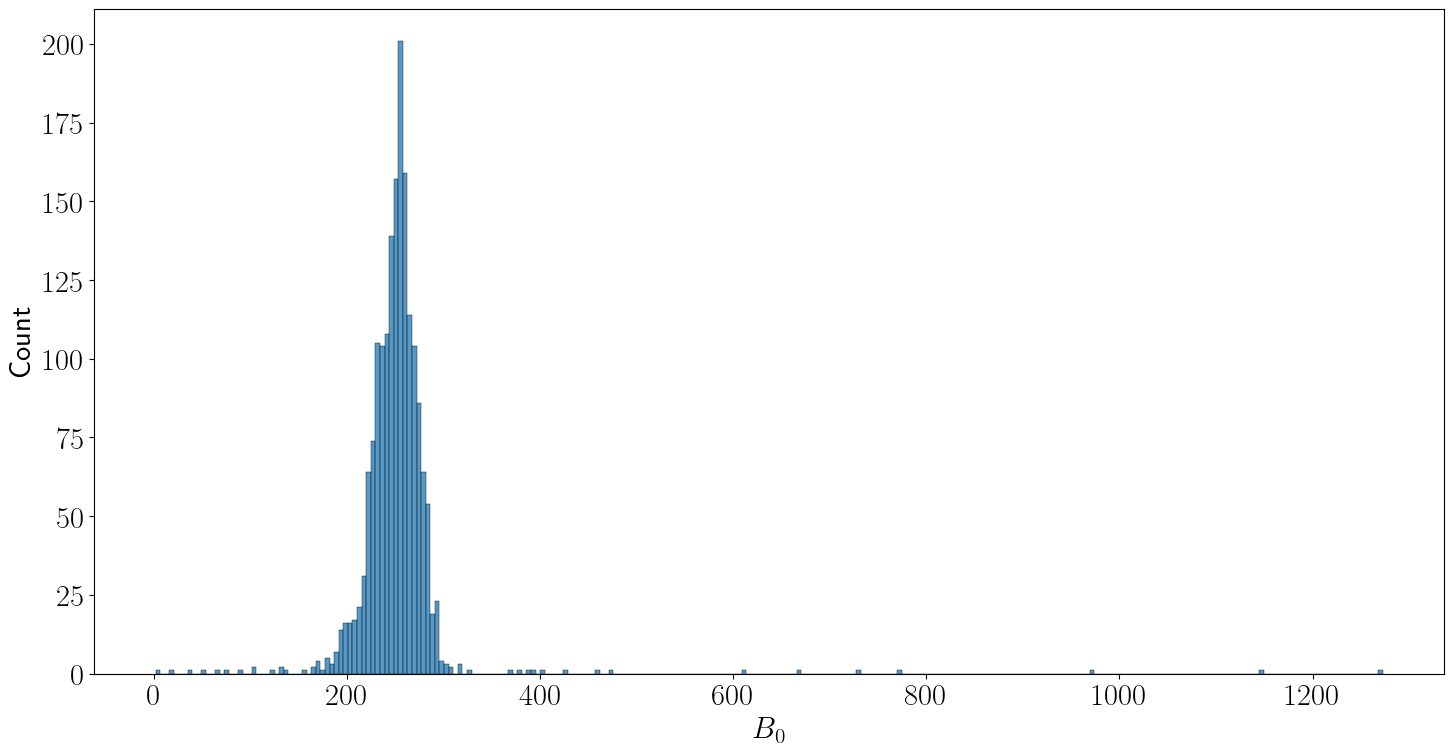

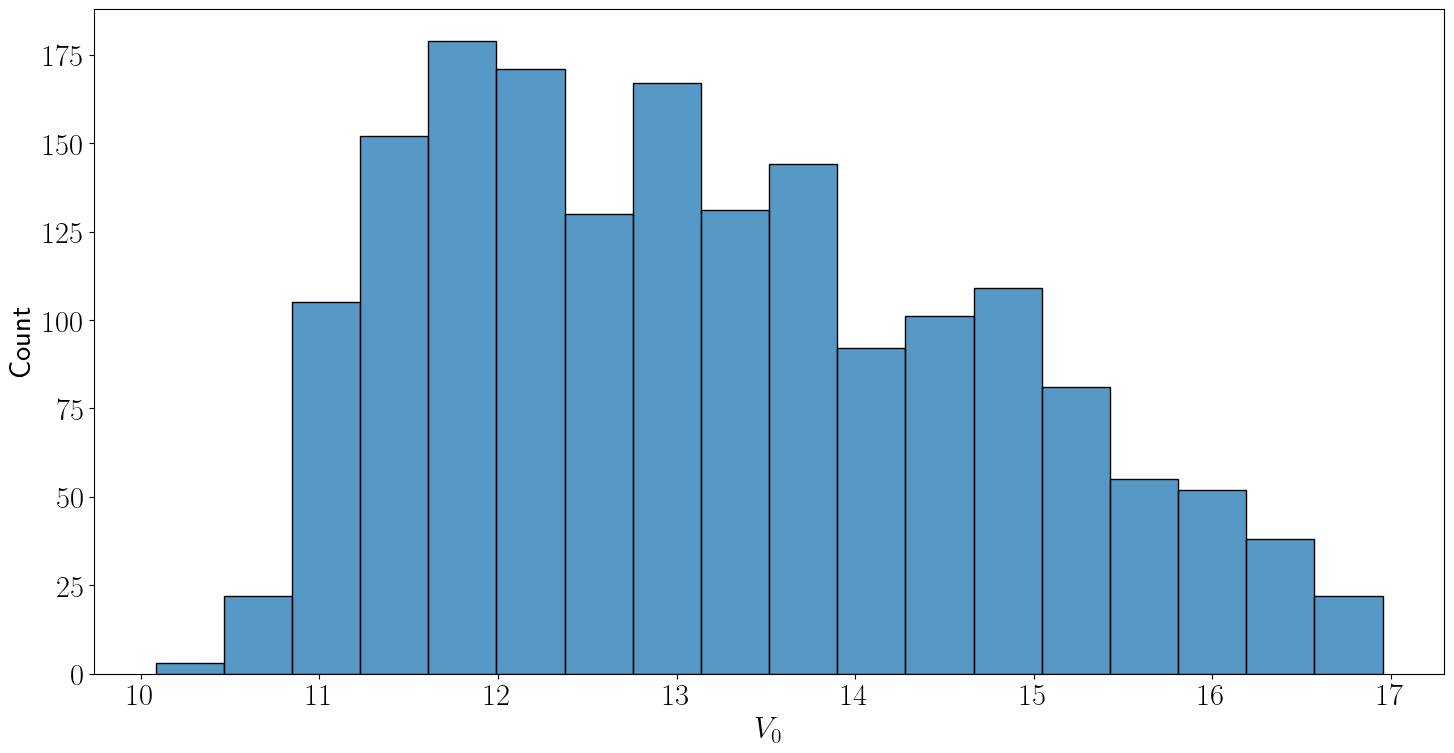

In [14]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

In [15]:
BS.sort_values(by='B0', inplace=True)

Text(11.109495, -7.81368, 'Cr_pv8Co_pv16.C36-AABBB.FM')

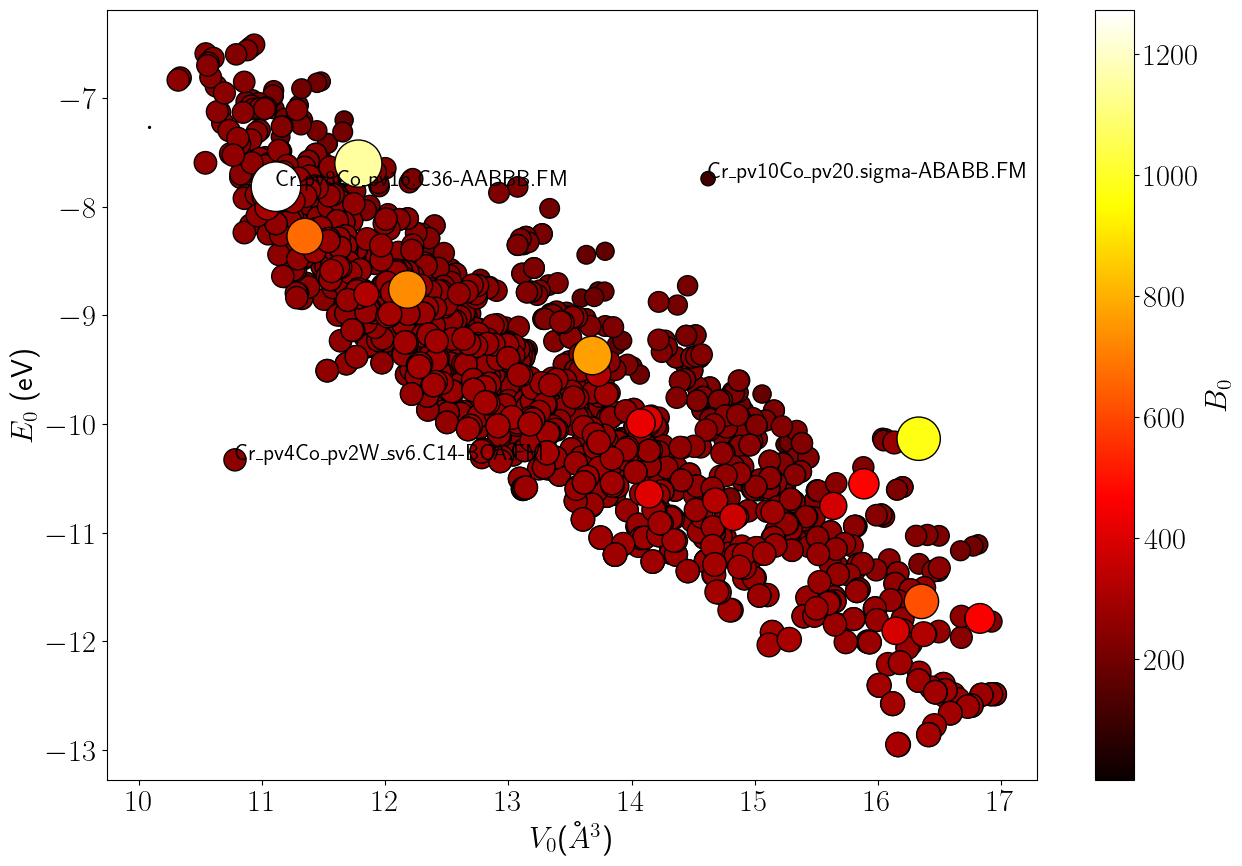

In [16]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(targets['E0']+' (eV)')
plt.xlabel(targets['V0']+'($\AA^3$)')
cbar.set_label(targets['B0'])
outlier_right = BS[(BS['E0']>-8) & (BS['V0']>14)].index
outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )
plt.annotate(outlier_right[0],*BS.loc[outlier_right][['V0', 'E0']].values,fontsize=16)
outlier_high_b0 = BS[BS['B0']>1100].index
plt.annotate(outlier_high_b0[0],*BS.loc[outlier_high_b0][['V0', 'E0']].values, fontsize=16)

from the plots below, we only would put in the paper the one with _V_0 in x, E_0 in y and B_0 in color coding_

## Very low B0 or very High B0

In [17]:
BS[(BS['B0'] < 150) | (BS['B0']>350)].B0.sort_values()

index
Cr_pv4Co_pv25.chi-BABB.FM               1.777361
Cr_pv16Co_pv4W_sv4.C36-BACAA.FM        19.348360
Cr_pv8Co_pv12W_sv4.C36-AACBB.FM        36.753632
Cr_pv4Co_pv12W_sv13.chi-CABC.FM        49.612461
Cr_pv4Co_pv8W_sv1.mu-CBAAB.FM          67.987767
Cr_pv8Co_pv16.C36-BAABB.FM             76.587431
Cr_pv10Co_pv14.C36-ABBAB.FM            87.421066
Cr_pv14Co_pv6W_sv4.C36-AACBA.FM       104.539707
Cr_pv10Co_pv20.sigma-ABABB.FM         106.045764
Cr_pv14Co_pv4W_sv6.C36-ABACA.FM       120.679637
Cr_pv8Co_pv4W_sv12.C36-ABACC.FM       132.666439
Cr_pv14Co_pv10.C36-AABAB.FM           132.874213
Cr_pv3Co_pv10.mu-ABBAB.FM             136.585559
Cr_pv8Co_pv4W_sv18.sigma-CBCCA.FM     371.402142
Cr_pv6W_sv7.mu-BBAAA.FM               380.255362
Cr_pv5W_sv24.chi-AABB.FM              390.229101
Cr_pv12Co_pv5W_sv12.chi-BBAC.FM       394.483223
Cr_pv8Co_pv6W_sv16.sigma-BBCAC.FM     404.734939
Co_pv13W_sv16.chi-ABAB.FM             426.930807
Cr_pv4W_sv20.C36-BABBB.FM             458.517772
Co_pv4W_sv9.mu

## curate suspicious samples based on B0

In [18]:
BS = BS[(BS['B0'] > 150) & (BS['B0'] < 350)] #.B0.sort_values()

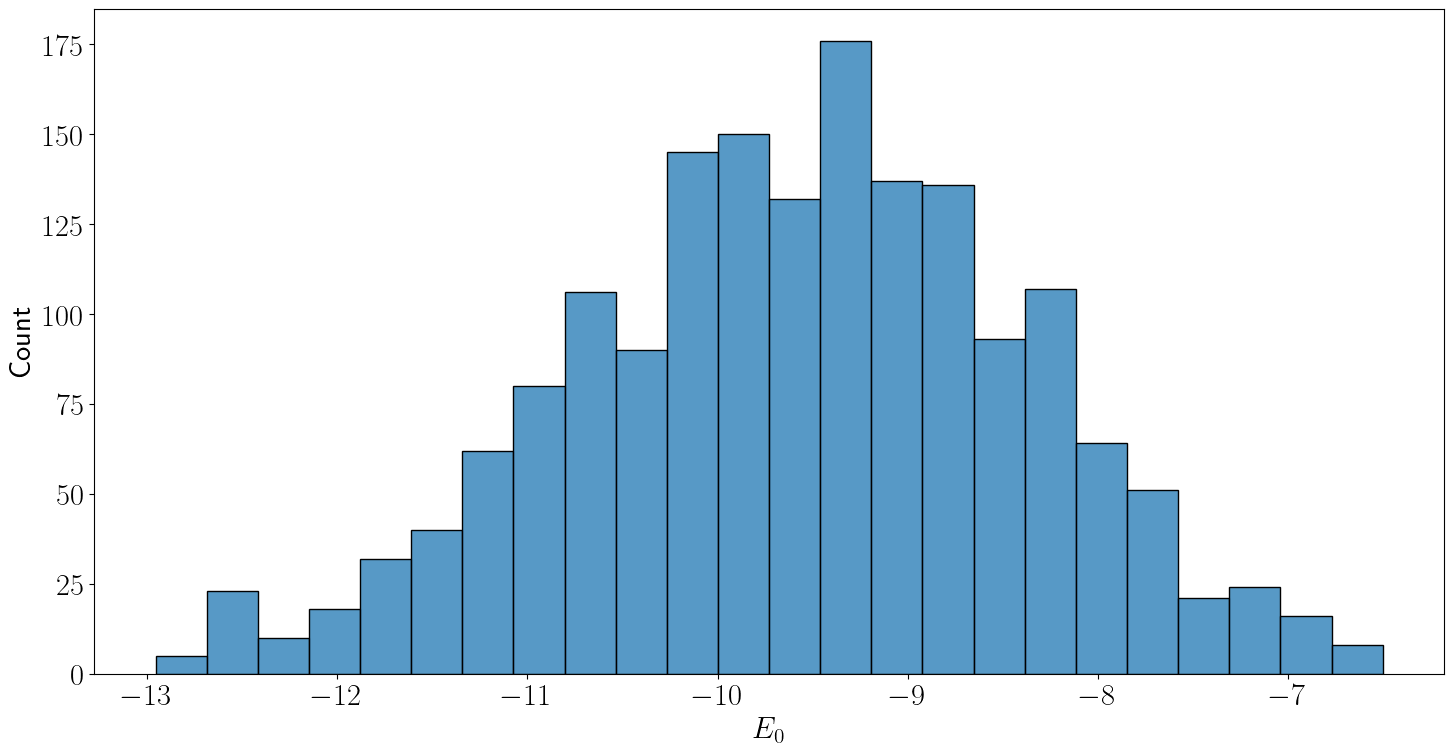

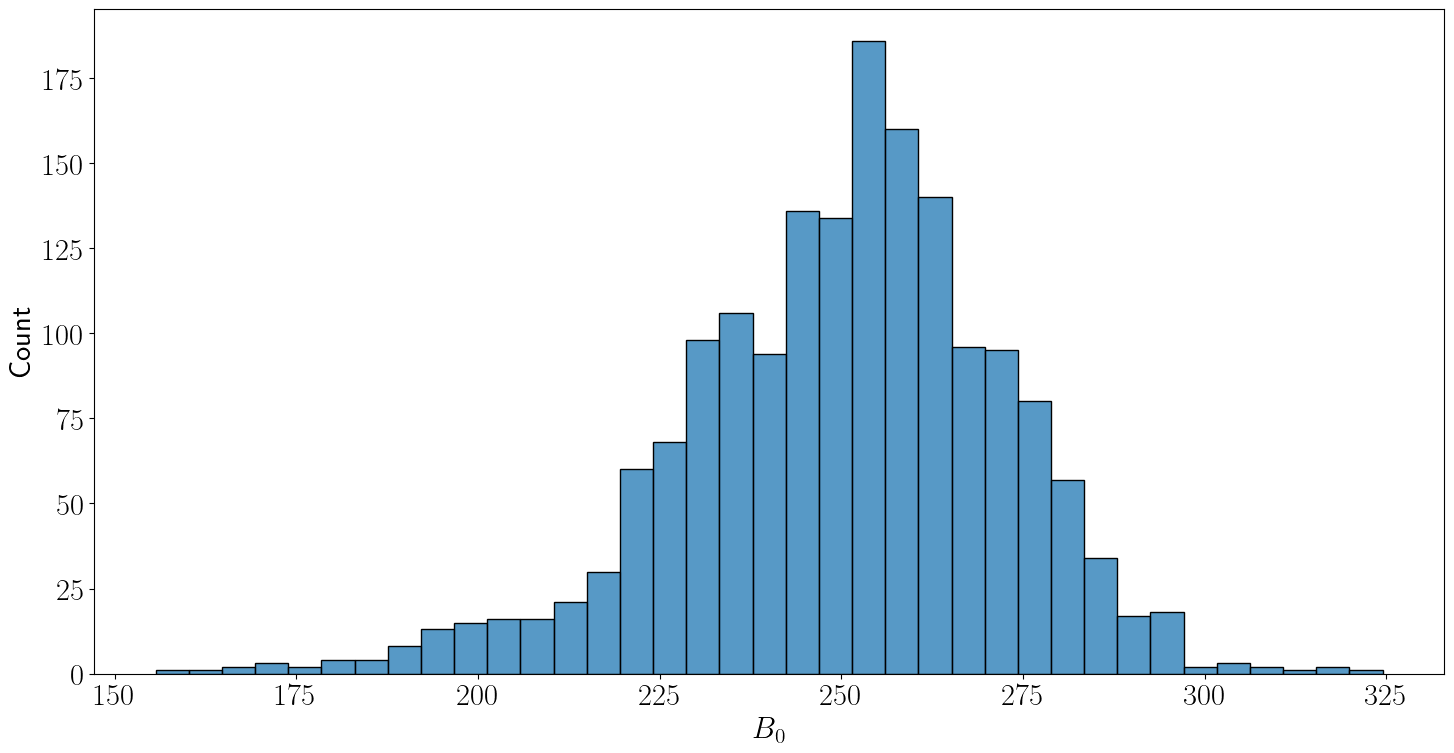

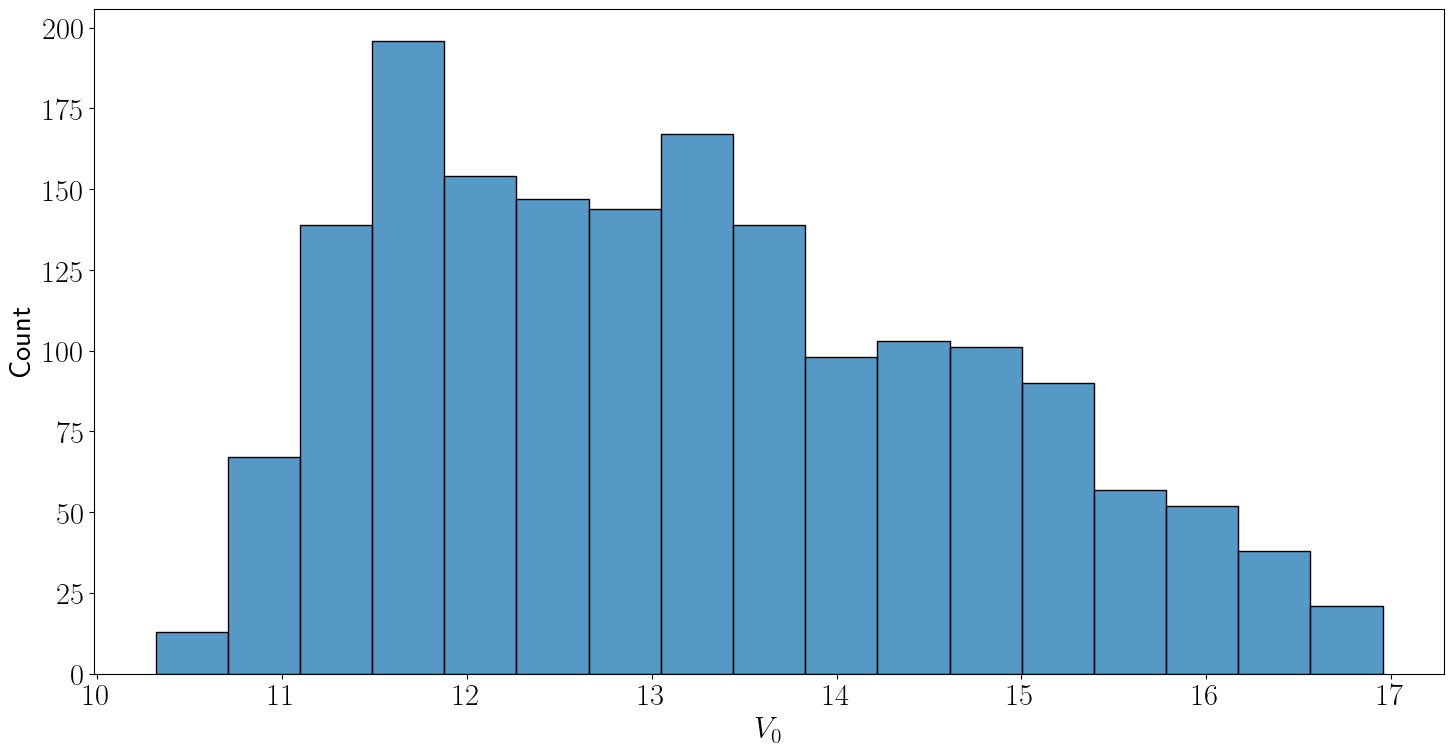

In [24]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# Pair Plots

In [19]:
ToPlot = BS[list(targets.keys())] #+['Phase']]
ToPlot.columns = list(targets.values()) #+['Phase']

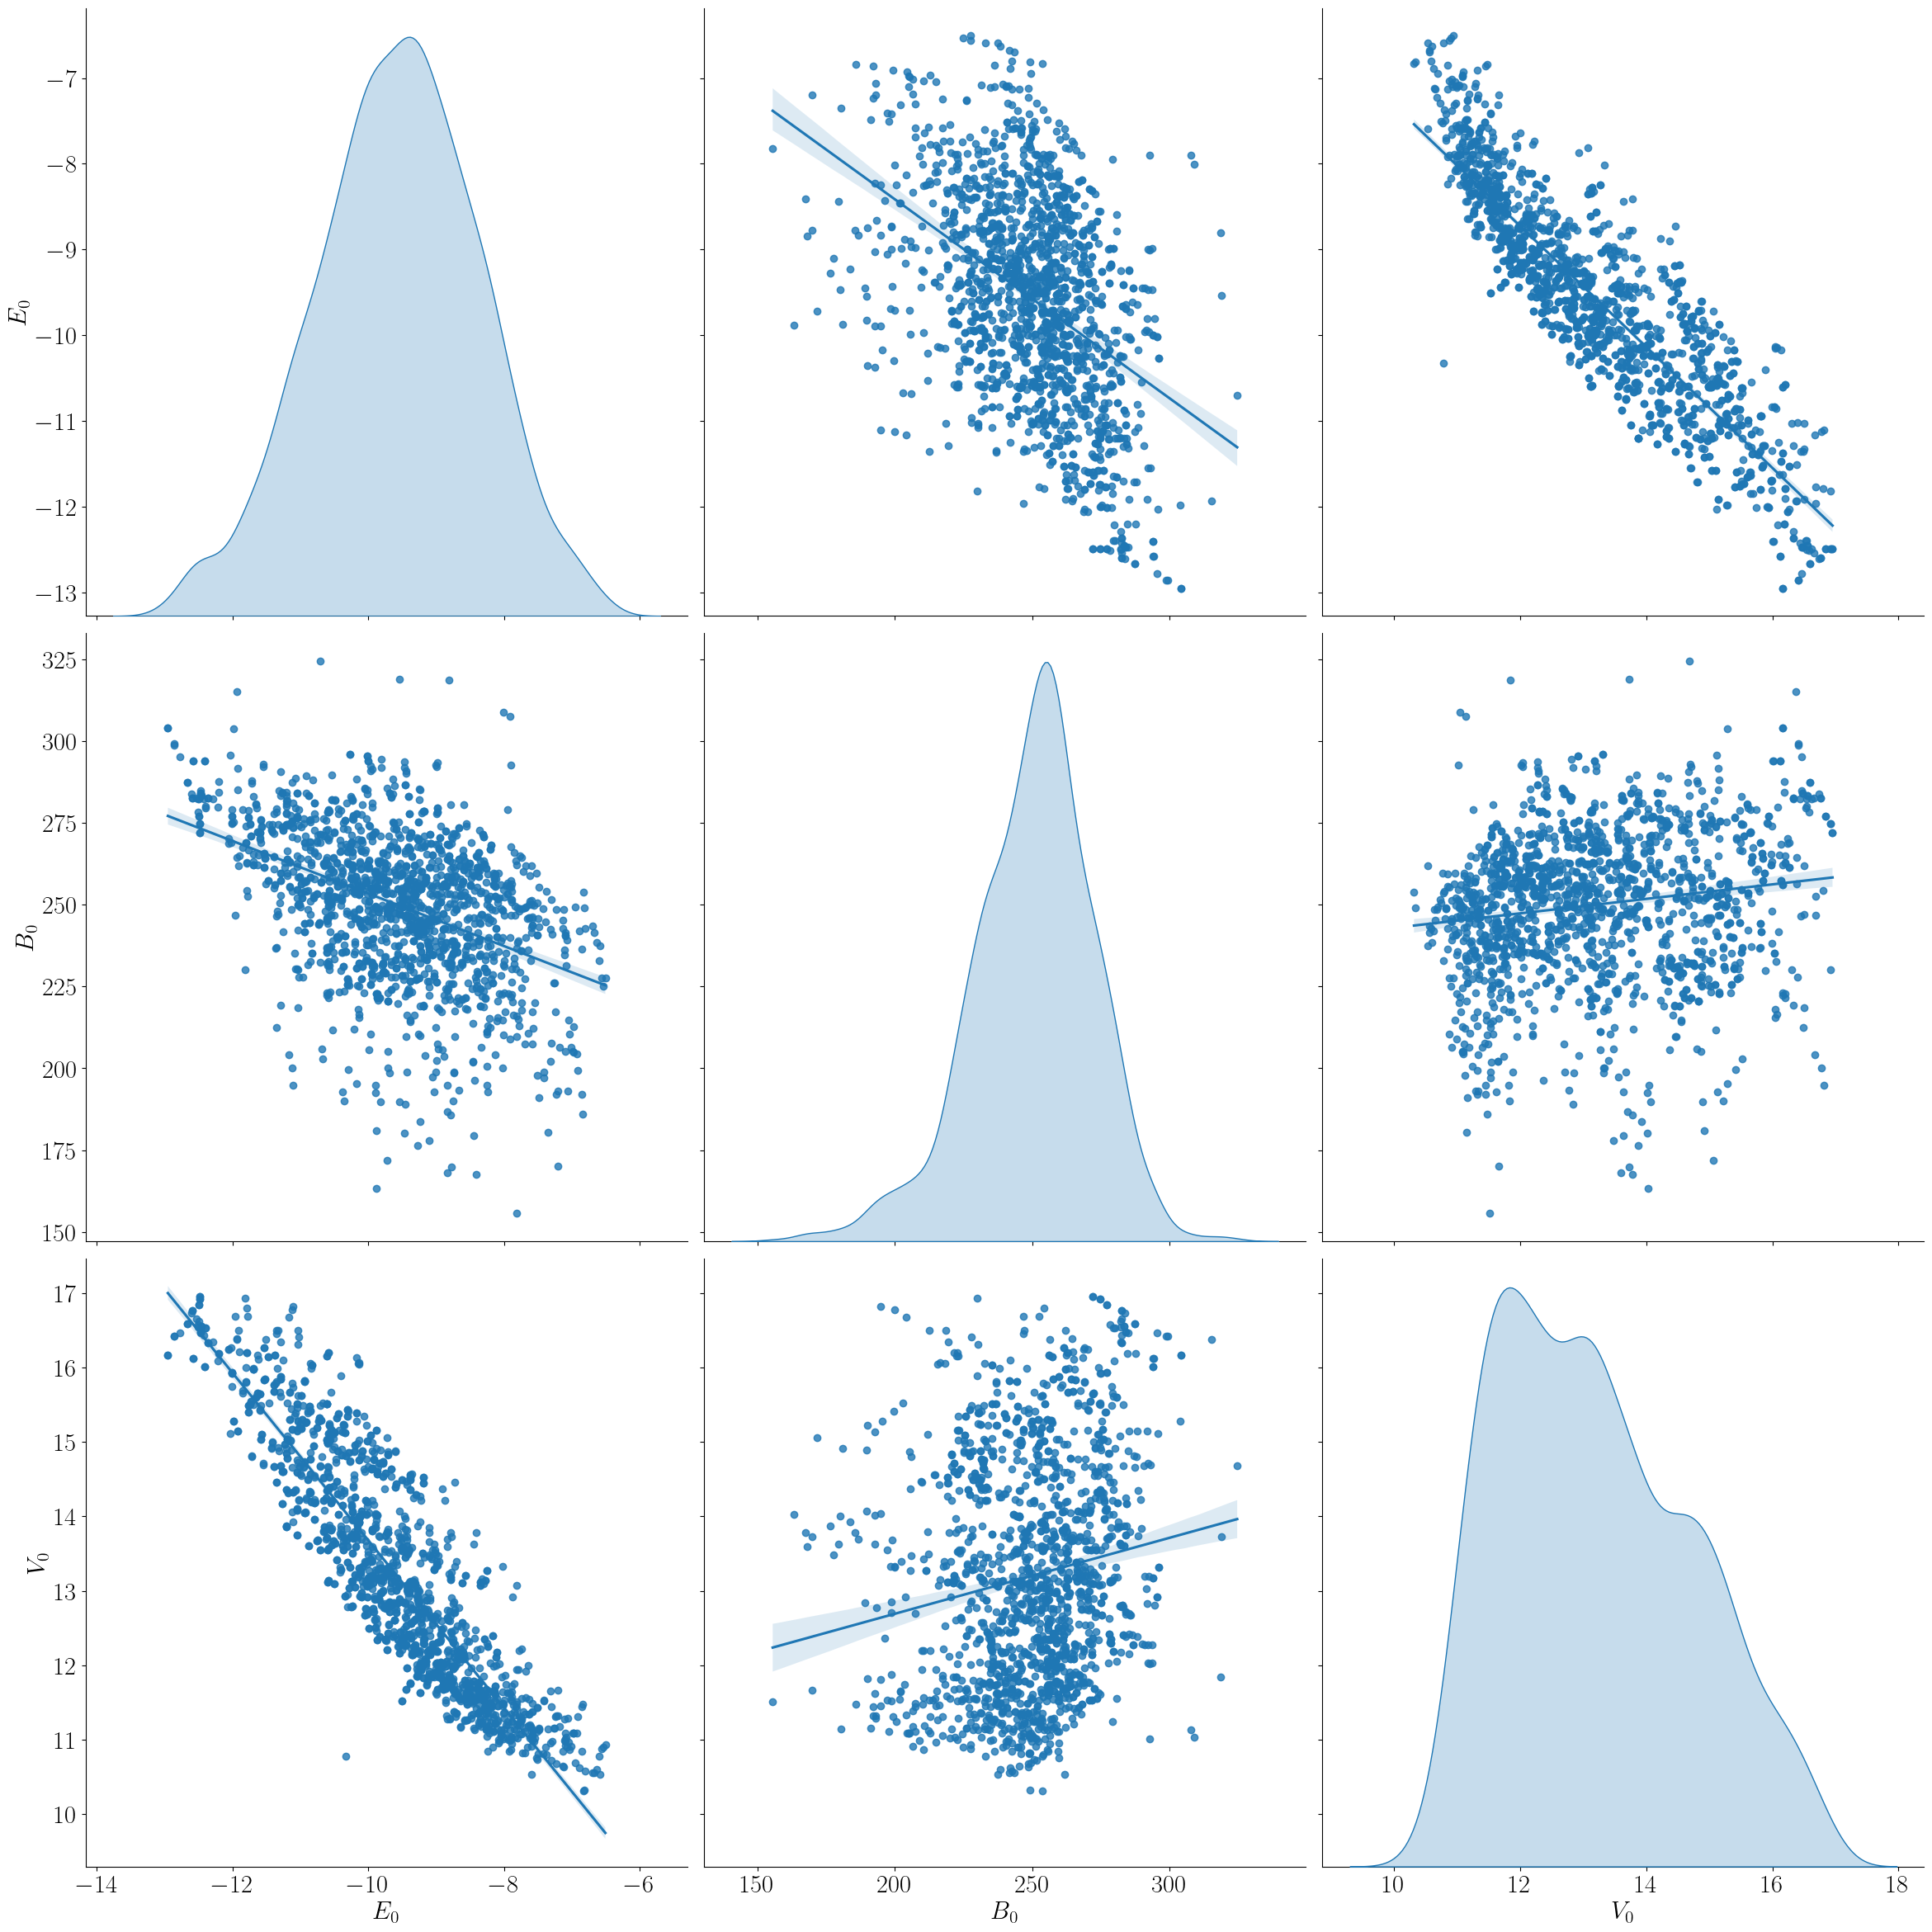

In [20]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# convex hulls ?

In [21]:
import pandas as pd
from scipy.spatial import ConvexHull

In [22]:
PhaseBS = {}
verts = {}

for phase in BS.Phase.unique():
    PhaseBS[phase] = BS[BS.Phase == phase]

In [23]:
for phase, bs in PhaseBS.items():
    if bs.shape[0] <= 1:
        continue  # cant make CH with less than 1 sample
    chull = ConvexHull(bs[['Fe_pv','EF']])
    verts[phase] = chull.vertices

KeyError: "['Fe_pv'] not in index"

In [ ]:
irrelevant = ['sigma', 'chi', 'hcp','A15','C15' ,'fcc']

In [ ]:
fig = plt.figure()
ax = fig.add_axes([0.2,0.2,0.6,0.8])
for phase, vertices in verts.items():
    if phase not in irrelevant:
    #    plt.plot(bs['Fe_pv'], bs['EF'], 'o')
        ax.plot(PhaseBS[phase]['Fe_pv'][vertices], PhaseBS[phase]['EF'][vertices], label=phase)
ax.set_ylim([-0.05, 0.1])
ax2 = fig.add_axes([0.8, 0.2, 0.2, 0.8], sharey=ax)
ax2.hist(BS['EF'], bins=100, orientation='horizontal')
ax2.set_xlabel('counts')
ax2.yaxis.set_visible(False)
ax.set_xlabel('$x_{Fe}$')
ax.set_ylabel('$\Delta E_f$ (eV/atom)')
ax.legend()

In [ ]:
BS.to_pickle(os.path.join(dataset, f'FurtherCuratedParsedBriefSummary.pkl'))

# Compositions

In [ ]:
import plotly.express as pe

In [2]:
BS

NameError: name 'BS' is not defined

In [ ]:
pe.scatter_ternary(B)